# Gibbs sampling on a directed factor graph


<div class="note"><span class="note-t">In brief</span>
<p>We build a 4×4 Ising Gibbs sampler from a one-spin factor, checkerboard tiling, and a repeated directed factor graph. Because a 4×4 lattice has only 65,536 states, we can check zero-field sampling, temperature sweeps, and field-conditioned pattern completion against exact enumeration rather than against another approximation.</p>
</div>

<div class="note"><span class="note-t">Prerequisite</span>
<p>For background on factors, <a href="15_intro_to_factors.ipynb">15 - Introduction to factors and directed factor graphs</a> introduces the core abstraction before this full Ising sampler.</p>
</div>

A **factor** in Torx is a directed conditional $P(\text{output} \mid \text{inputs})$. A custom factor supplies its input and output specs along with `sample` and `init_params`. The one-spin factor here also implements an exact `log_probability`, which gives us an analytic reference for that one-spin conditional only.

A parametrised stochastic circuit (PSC) is an ordered list of stochastic gates applied to an initial state. This tutorial builds nothing of that kind: no PSC, no compiled circuit, and no simulator. Everything below is hand-written factors wired into a graph, which keeps the mechanics visible.

[Gibbs sampling](#ref-geman1984) updates one variable at a time from its conditional, and it is not the main use case Torx is built for. For a dedicated Gibbs sampling library, use [thrml](https://github.com/extropic-ai/thrml). We use it here anyway because a Gibbs sampler happens to exercise the whole `DFG` workflow in one example: a custom factor with an analytic conditional, weight tying, tiling, deterministic reassembly, and an exact finite-state reference to check the result against.

<details class="tx-disclosure"><summary>Term: Gibbs and chromatic Gibbs sampling</summary><p>Gibbs sampling resamples variables from their conditional target distributions. In <a href="#ref-gonzalez2011">chromatic Gibbs sampling</a>, same-color spins have no edges between them, so they are conditionally independent given the other color and can update together before the colors swap.</p></details>

The coloring idea comes from [notebook 06](06_ising_sampling_contrastive_divergence.ipynb), where the lattice is colored so non-adjacent spins update together. Notebook 06 runs that idea on an 8-spin ring with `PNOT` gates, while here we write the same chromatic-Gibbs conditional as hand-built factors on a $4\times4$ torus. The two notebooks share the conditional update and the coloring strategy but use different graphs and Ising distributions.

One design choice matters for everything that follows: the graph receives the per-site `field` as an input rather than as a baked-in weight. With a zero field the model is the symmetric Ising magnet, and with a finite field on selected sites the very same graph performs field-conditioned pattern completion, with no rewiring in between.

The grid is a $4\times4$ torus, which is small enough that all $2^{16} = 65{,}536$ configurations fit in memory. That is the whole reason we can be strict here: the exact distribution is available by brute force for any fixed field, so every check below compares against it rather than against another sampler.

<details class="tx-disclosure"><summary>What runs where?</summary><ul>
<li>Torx runs the stochastic factor, tiling, directed factor graph, and weight-tied chain.</li>
<li>Notebook code builds the exact distribution and quantitative comparisons.</li>
<li><code>examples/helpers/_plots_schematics.py</code> owns lattice geometry and its diagram.</li>
<li><code>examples/helpers/_plots_sampling.py</code>, <code>examples/helpers/_notebook_paths.py</code>, and <code>examples/helpers/_notebook_style.py</code> own batching, statistics, plots, paths, and styling.</li>
</ul></details>

The main steps are:

1. set up the $4\times4$ Boltzmann machine and draw its `DFG`,
2. write the one-spin update as a custom factor and check its draws against the conditional it reports analytically,
3. tile the update into two color blocks and wire them into an explicit `DFG` for one Gibbs sweep,
4. repeat that sweep as a weight-tied chain, build the exact distribution by brute-force enumeration, and check the sampler against it,
5. sweep the temperature and watch the magnet order as it cools,
6. drive the model with a site-varying field and compare the sampler against that same exact distribution spin by spin and connection by connection, and
7. drive the graph with a strong finite field for field-conditioned pattern completion.

## Setup

The setup cells put the local helper directory on the path, then fix the plotting style and the seed so every figure and draw below reproduces.

In [1]:
from pathlib import Path
import sys

SEARCH_ROOTS = (Path.cwd().resolve(), *Path.cwd().resolve().parents)
HELPER_DIR = next(
    (
        root / "examples" / "helpers"
        for root in SEARCH_ROOTS
        if (root / "examples" / "helpers").is_dir()
    ),
    None,
)
if HELPER_DIR is None:
    raise FileNotFoundError("could not locate examples/helpers from the current directory")
ROOT = HELPER_DIR.parent
sys.path.insert(0, str(HELPER_DIR))

In [2]:
import equinox as eqx
import jax
import jax.numpy as jnp
import numpy as np



In [3]:
from _notebook_paths import figure_dir
from _notebook_style import apply_notebook_style, make_savefig
import _plots_sampling as P_samp
import _plots_schematics as P_sch



In [4]:
from torx import (
    AbstractHasLogProbability,
    AbstractReferenceFactor,
    ChainFactor,
    DeterministicFactor,
    DFG,
    Site,
    TiledFactor,
)

In [5]:
apply_notebook_style()
FIGURE_DIR = figure_dir(ROOT)
SEED = 15
rng = np.random.default_rng(SEED)


savefig = make_savefig(FIGURE_DIR)

## The model as a Boltzmann machine

The model is a $4\times4$ grid of spins with periodic boundaries, so every spin has exactly four neighbors. This is the finite Ising model used as a Boltzmann machine by [Ackley, Hinton, and Sejnowski (1985)](#ref-ackley1985).

The grid holds 16 spins and 32 connections, and the state is stored as spins $s \in \{-1, +1\}$. Internally each update draws a Bernoulli **pbit** in $\{0, 1\}$ and maps it to the stored spin via $s = 2\,\text{pbit} - 1$, so the two representations describe the same variable in different coordinates. The neighbor lists, connection list, and checkerboard coloring come from `examples/helpers/_plots_schematics.py`.

The energy says what the model prefers. Neighboring spins prefer to agree, and a per-site field $b_i$ biases each spin.

$$
H(s) = -J\,\sum_{(i,j)\in E} s_i\, s_j \;-\; \sum_i b_i\, s_i,
\qquad \pi(s) \propto e^{-\beta H(s)}.
$$

Lower energy means higher probability, and $\beta$ is the inverse temperature.

With $b = 0$ the model is the symmetric Ising magnet. A finite nonzero $b_i$ biases spin $i$ but does not hold it fixed, which is what makes the pattern completion at the end of the notebook a sampling problem rather than a clamping trick.

In [6]:
GRID = 4
N = GRID * GRID
J = 1.0  # ferromagnetic coupling: neighbors prefer to agree
beta = 0.45  # baseline inverse temperature for the low-temperature comparison

EDGES = P_sch.lattice_edges()
COLOR_A, COLOR_B = P_sch.checkerboard_colors()
NEIGHBORS_OF = [P_sch.lattice_neighbors(i) for i in range(N)]

print(
    f"{N} spins, {len(EDGES)} connections, two colors of size "
    f"{len(COLOR_A)} and {len(COLOR_B)}"
)
print(f"every spin has {len(NEIGHBORS_OF[0])} neighbors (periodic)")

16 spins, 32 connections, two colors of size 8 and 8
every spin has 4 neighbors (periodic)


The figure below is the lattice the `DFG` will sweep, drawn so that the update order is visible.

The 16 spins split into two color blocks. Solid links are the neighbor dependencies inside the grid, and the dashed stubs are the periodic wrap-around connections that close the lattice into a torus. The two colors are the two checkerboard update groups, and every spin reads four neighbors that all lie in the other block, which is what makes a whole block safe to update at once. Color `A` reads the incoming state, and color `B` then reads the freshly updated color `A`.

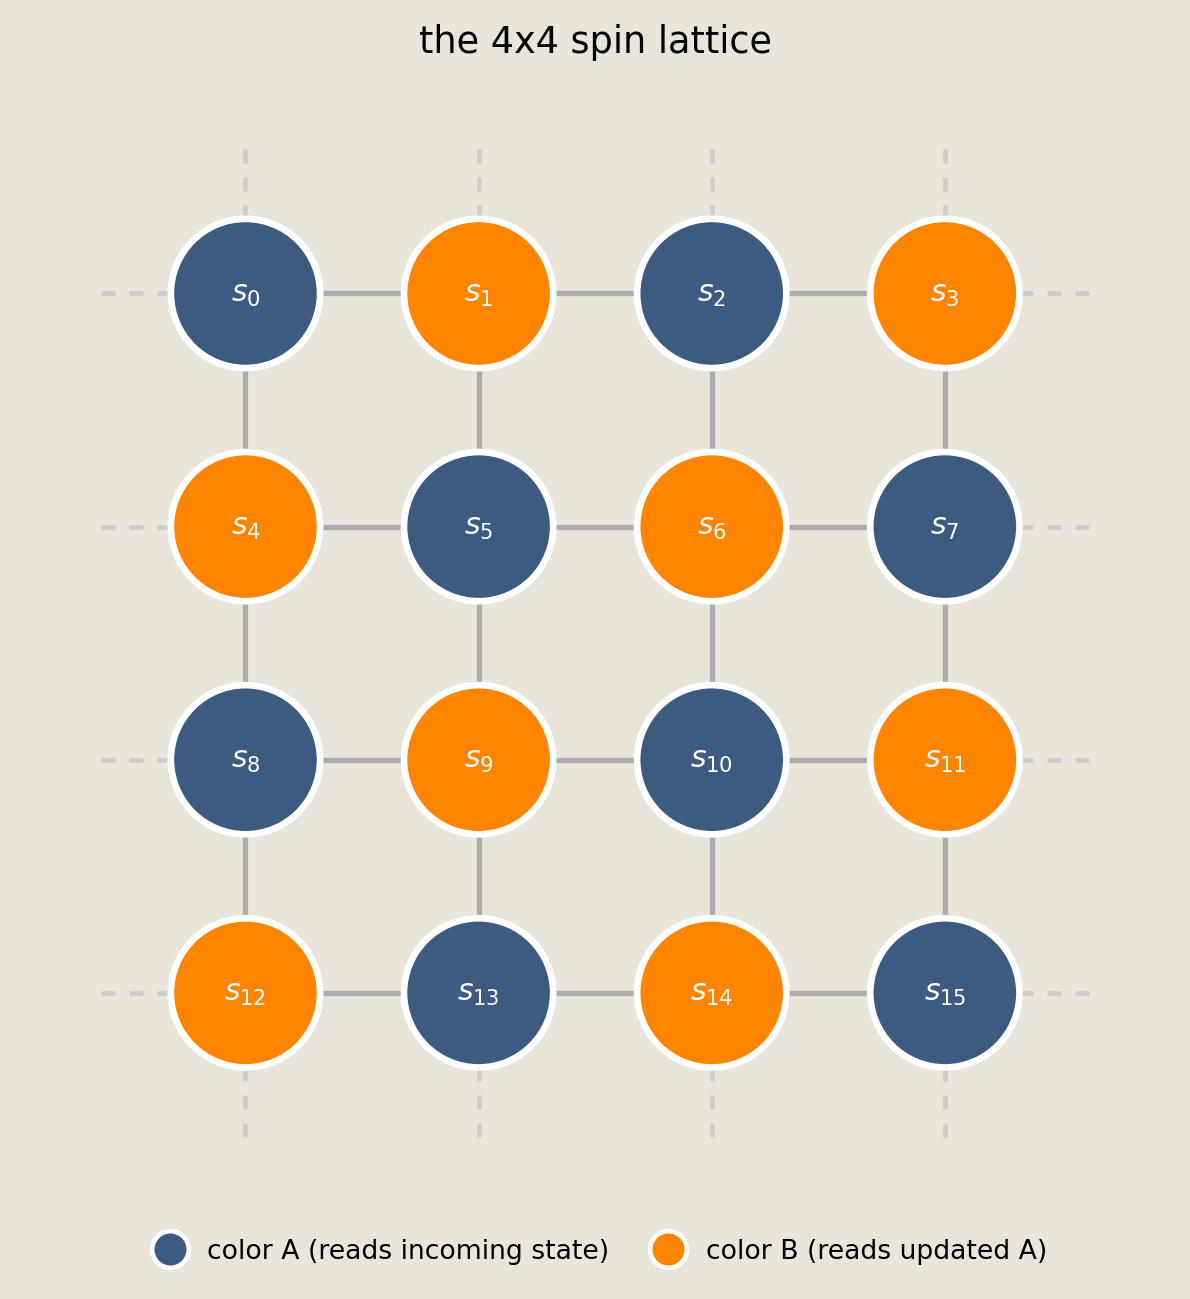

In [7]:
fig = P_sch.plot_factor_graph()
savefig(fig, "16_factor_graph")

## The per-spin update as a factor

The smallest piece of the model is a single spin update: given a spin's four neighbors and its local `drive`, draw its new value. Get that one conditional right and the rest of the notebook is wiring.

That update is one factor: a directed conditional that implements `sample` and `init_params` alongside its specs.

The update draws a Bernoulli pbit in $\{0, 1\}$ with probability $\sigma(2\gamma_i)$, then maps it to the stored spin $s_i = 2\,\text{pbit} - 1 \in \{-1, +1\}$. Here $\sigma$ is the logistic sigmoid and the local field $\gamma_i$ collects the neighbors and the `drive`.

The draw uses `jax.random.bernoulli`. The `drive` and the coupling parameter the kernel consumes already carry the inverse temperature $\beta$, because we supply $\text{drive}_i = \beta\,b_i$ and $j = \beta J$, so $\gamma_i$ is the $\beta$-scaled local field. The brute-force `exact_distribution` below instead takes the raw physical field $b_i$ and applies $\beta$ itself, so the two paths agree on the same physics from different inputs.

$$
\gamma_i = \beta\,b_i + \beta J\,\sum_{j\in\mathcal{N}(i)} s_j,
\qquad
P(s_i = +1 \mid \mathcal{N}(i),\, b_i) = \sigma(2\gamma_i).
$$

In [8]:
SPIN = jax.ShapeDtypeStruct((), jnp.int32)  # one spin, -1 or +1
NEIGHBORS = jax.ShapeDtypeStruct((4,), jnp.int32)  # its four neighbor spins
DRIVE = jax.ShapeDtypeStruct((), jnp.float32)  # this spin's local drive (beta * b_i)




In [9]:
class SpinUpdate(AbstractReferenceFactor, AbstractHasLogProbability):
    r"""$P(s_i \mid \mathcal{N}(i))$: stored as a spin in $\{-1, +1\}$, drawn via one
    Bernoulli pbit with probability $\sigma(2\gamma_i)$ then mapped to a spin.

    The `drive` input is the temperature-scaled bias `beta * b_i`; the raw
    field `b_i` is scaled before it reaches the kernel. Besides the
    specs, a custom factor implements `sample` and `init_params`, and
    `AbstractReferenceFactor` supplies the generic `sample_with_references`.
    `log_probability` exactly evaluates this one-spin conditional only, not the
    joint 16-spin distribution or the full-chain distribution.
    """

    input_ports: dict[str, jax.ShapeDtypeStruct] = eqx.field(static=True)
    output_spec: jax.ShapeDtypeStruct = eqx.field(static=True)

    def __init__(self):
        self.input_ports = {"neighbors": NEIGHBORS, "drive": DRIVE}
        self.output_spec = SPIN

    def init_params(self, key):
        return {"j": jnp.zeros((), jnp.float32)}

    def _local_field(self, inputs, params):
        return inputs["drive"] + params["j"] * inputs["neighbors"].sum()

    def sample(self, key, inputs, params, info=None, site_info=None, return_aux=False):
        # draw a Bernoulli pbit in {0, 1}, then map to the stored spin {-1, +1}
        draw = jax.random.bernoulli(
            key, jax.nn.sigmoid(2 * self._local_field(inputs, params))
        ).astype(jnp.int32)
        spin = 2 * draw - 1
        return (spin, None) if return_aux else spin

    def log_probability(
        self, inputs, outputs, params, info=None, site_info=None, return_aux=False
    ):
        # Exact one-spin conditional only: P(s_i | neighbors, drive).
        valid = (outputs == 1) | (outputs == -1)
        log_prob = jnp.where(
            valid,
            jax.nn.log_sigmoid(2 * self._local_field(inputs, params) * outputs),
            -jnp.inf,
        )
        return (log_prob, None) if return_aux else log_prob

Now we probe the factor, because a conditional that is subtly wrong would still produce plausible-looking lattices later. We fix the neighbors and `drive` by hand, compute the resulting local field $\gamma$, draw the update many times, and check that the fraction of $+1$ spins matches $\sigma(2\gamma)$.

This is the single-spin check: the factor samples its conditional, and it reports that same conditional analytically.

In [10]:
probe = SpinUpdate()

probe_neighbors = jnp.array([1, 1, 1, -1], dtype=jnp.int32)  # sums to +2
probe_drive = 0.30  # scaled local bias the kernel consumes
probe_coupling = beta * J
probe_params = {"j": probe_coupling}
gamma = probe_drive + probe_coupling * probe_neighbors.sum()
target_p = float(jax.nn.sigmoid(2 * gamma))

n_probe = 20000
keys = jax.random.split(jax.random.key(SEED), n_probe)
inputs = {"neighbors": probe_neighbors, "drive": probe_drive}
draws = jax.vmap(lambda k: probe.sample(k, inputs, probe_params))(keys)
probe_p = float((np.asarray(draws) == 1).mean())

print(f"gamma = {float(gamma):.4f}  ->  target sigmoid(2*gamma) = {target_p:.4f}")
print(f"sampled fraction of +1 spins                     = {probe_p:.4f}")

gamma = 1.2000  ->  target sigmoid(2*gamma) = 0.9168
sampled fraction of +1 spins                     = 0.9183


With the empirical fraction matched, we read the same conditional back analytically to confirm that `log_probability` describes the distribution `sample` actually draws from. The analytic value should agree with the sampled one, and the two outcomes should sum to one.

In [11]:
logp_p_up = float(np.exp(probe.log_probability(inputs, 1, probe_params)))
logp_mass = float(
    np.exp(probe.log_probability(inputs, 1, probe_params))
    + np.exp(probe.log_probability(inputs, -1, probe_params))
)

print(
    f"log_probability gives P(+1) = {logp_p_up:.4f},  outcomes sum to {logp_mass:.6f}"
)
np.testing.assert_allclose(probe_p, target_p, atol=0.01)
np.testing.assert_allclose(logp_p_up, target_p, atol=1e-5)
np.testing.assert_allclose(logp_mass, 1.0, atol=1e-6)

log_probability gives P(+1) = 0.9168,  outcomes sum to 1.000000


## Wiring the lattice into a directed factor graph

The two checkerboard colors are the two Gibbs blocks. Block Gibbs means we resample a whole group of variables in one move instead of one variable at a time, which is valid here because no two spins of the same color are neighbors, so inside a block the conditionals do not depend on each other. Every spin in a block updates from the same conditional, so each block is the single `SpinUpdate` factor wrapped in a `TiledFactor`: one tile per spin, eight tiles per block.

The tiles share one coupling, and each tile receives its own neighbors and `drive` as data. The geometry never changes during sampling, so we precompute each tile's neighbor indices once.

In [12]:
SPINS = jax.ShapeDtypeStruct((N,), jnp.int32)  # the full state
DRIVES = jax.ShapeDtypeStruct((N,), jnp.float32)  # per-site drive (beta * field)
BLOCK = len(COLOR_A)  # 8 spins per color
BLOCK_SPINS = jax.ShapeDtypeStruct((BLOCK,), jnp.int32)



In [13]:
COLOR_A_IDX = jnp.array(COLOR_A, dtype=jnp.int32)
COLOR_B_IDX = jnp.array(COLOR_B, dtype=jnp.int32)
position_in_a = {site: tile for tile, site in enumerate(COLOR_A)}



In [14]:
# Per-tile neighbor lookups, fixed by the geometry. Color A reads its four
# neighbors out of the incoming state; color B reads them out of the freshly
# updated color A block (every neighbor of a color B site is a color A site).
A_NEIGHBORS = jnp.array([NEIGHBORS_OF[i] for i in COLOR_A], dtype=jnp.int32)
B_NEIGHBORS = jnp.array(
    [[position_in_a[j] for j in NEIGHBORS_OF[i]] for i in COLOR_B], dtype=jnp.int32
)

Wiring a `Site` into a `DFG` means saying where its inputs come from, which is the job of a porting function. Each block needs one that slices its tiles' neighbors and `drive` out of the parent outputs, and a third function then scatters the two blocks back into one state vector.

In [15]:
def gather_block_a(parent_outputs):
    spins, drives = parent_outputs
    return {"neighbors": spins[A_NEIGHBORS], "drive": drives[COLOR_A_IDX]}




In [16]:
def gather_block_b(parent_outputs):
    """Route block-A spins and B-site drives into block B's kernel inputs."""
    block_a, drives = parent_outputs
    return {"neighbors": block_a[B_NEIGHBORS], "drive": drives[COLOR_B_IDX]}




In [17]:
def scatter_blocks(inputs, site_info):
    """Place the two color blocks back into one lattice-ordered state vector."""
    state = jnp.zeros(N, dtype=jnp.int32)
    state = state.at[COLOR_A_IDX].set(inputs["block_a"])
    state = state.at[COLOR_B_IDX].set(inputs["block_b"])
    return state

In [18]:
block = TiledFactor(SpinUpdate(), BLOCK, weight_tied=True)  # 8 spins in parallel
reassemble = DeterministicFactor(
    scatter_blocks, {"block_a": BLOCK_SPINS, "block_b": BLOCK_SPINS}, SPINS
)

With the pieces in hand, we wire the three `Site` objects into the `DFG` that performs one sweep.

Each block updates all of its spins in parallel, so a block appears in the graph as one tiled factor rather than as eight separate `Site` objects.

In [19]:
sites = (
    Site(
        "block_a",
        block,
        parents=("spins", "drive"),
        porting_fn=gather_block_a,
        param_key="coupling",
        info_key=None,
        site_info=None,
    ),
    Site(
        "block_b",
        block,
        parents=("block_a", "drive"),
        porting_fn=gather_block_b,
        param_key="coupling",
        info_key=None,
        site_info=None,
    ),
    Site(
        "state",
        reassemble,
        parents=("block_a", "block_b"),
        porting_fn=("block_a", "block_b"),
        param_key=None,
        info_key=None,
        site_info=None,
    ),
)



In [20]:
sweep = DFG(
    sites=sites, input_ports={"spins": SPINS, "drive": DRIVES}, output_name="state"
)
print(
    f"directed factor graph: {len(sites)} sites "
    f"(2 tiled blocks of {BLOCK} + 1 reassembly)"
)

directed factor graph: 3 sites (2 tiled blocks of 8 + 1 reassembly)


## Running the chain

The `DFG` above performs exactly one Gibbs sweep, so sampling the model means repeating it. A weight-tied `ChainFactor` does that: it runs the same sweep for many steps with one shared coupling, which is the Torx idiom for a Markov chain Monte Carlo (MCMC) chain.

The `drive` input, which carries the $\beta$-scaled field, is a non-feedback input, so the chain holds it fixed at every step and threads only the spins from one sweep into the next.

We then run 200 sweeps on each of 4,000 independent chains and keep one final sample from each, which gives 4,000 draws that are independent by construction rather than 4,000 correlated points along a single trajectory.

In [21]:
n_steps = 200  # Gibbs sweeps per chain
settling_mark = 80  # heuristic marker shown on the settling trace
n_chains = 4000

chain = ChainFactor(sweep, n_steps=n_steps, feedback_porting_fn="spins", weight_tied=True)




In [22]:
def run(key, beta, init, field):
    # field is the raw physical field; scale it and the coupling by beta into the
    # drive the kernel consumes for this temperature.
    """Run the full `n_steps`-sweep chain at inverse temperature `beta`."""
    inputs = {"spins": init, "drive": beta * field}
    return chain.sample(key, inputs, params={"coupling": {"j": beta * J}})


@eqx.filter_jit
def run_many(keys, beta, inits, field):
    # reusable batched sampler; beta stays a traced scalar so changing the
    # temperature reuses this compile instead of recompiling per beta.
    """Batched `run` over chains."""
    return jax.vmap(lambda k, x: run(k, beta, x, field), in_axes=(0, 0))(keys, inits)




In [23]:
zero_field = jnp.zeros(N, dtype=jnp.float32)
inits = (
    jax.random.bernoulli(jax.random.key(SEED), 0.5, (n_chains, N)).astype(jnp.int32) * 2
    - 1
)
keys = jax.random.split(jax.random.key(SEED + 1), n_chains)
# Run independent chains from independent starts and keep one final state per chain.
samples = np.asarray(
    run_many(keys, jnp.asarray(beta, jnp.float32), inits, zero_field)
)
print(f"drew {samples.shape[0]} final-chain samples of {samples.shape[1]} spins each")

drew 4000 final-chain samples of 16 spins each


Before comparing distributions, we want a rough sense of whether 200 sweeps gives the chains room to settle. So we start many chains from a disordered state and track the **order parameter** at each sweep: the magnitude of the average spin, averaged across chains. It runs from 0 for a lattice with no net direction to 1 for a fully aligned one.

In the figure, the bold line is that mean and the band is the 16th to 84th percentile range across chains. The dashed line marks sweep 80, a reference we picked by hand so we can see whether the trace has levelled off well before the 200th sweep the chain actually runs.

In [24]:
n_trace = 1000  # chains tracked for the heuristic settling trace
trace_init = (
    jax.random.bernoulli(jax.random.key(SEED + 2), 0.5, (n_trace, N)).astype(jnp.int32)
    * 2
    - 1
)




In [25]:
@eqx.filter_jit
def settling_trace(key, init_state):
    # one lax.scan over sweeps, vmapped across chains: records the per-step order
    # parameter for every chain inside a single dispatch, no per-step host sync.
    """Record the per-sweep order parameter for chains from a disordered start."""
    def sweep_all(state, k):
        def one_sweep(kk, x):
            return sweep.sample(
                kk,
                {"spins": x, "drive": beta * zero_field},
                params={"coupling": {"j": beta * J}},
            )

        new = jax.vmap(one_sweep, in_axes=(0, 0))(
            jax.random.split(k, init_state.shape[0]), state
        )
        return new, jnp.abs(new.mean(axis=1))

    keys = jax.random.split(key, n_steps)
    _, orders = jax.lax.scan(sweep_all, init_state, keys)
    init_order = jnp.abs(init_state.mean(axis=1))
    return jnp.concatenate([init_order[None, :], orders], axis=0)




In [26]:
# (n_trace, n_steps + 1) for plotting
order_traces = np.asarray(settling_trace(jax.random.key(SEED + 4), trace_init)).T

The order parameter climbs off its disordered start and then flattens before the marker. Read that as a settling cue rather than as proof of mixing, because a single order parameter cannot tell us whether the chains move between the two mirror-image ordered states. The exact-distribution comparisons below are the real test, and they check the final-sample distribution at this 200-sweep runtime.

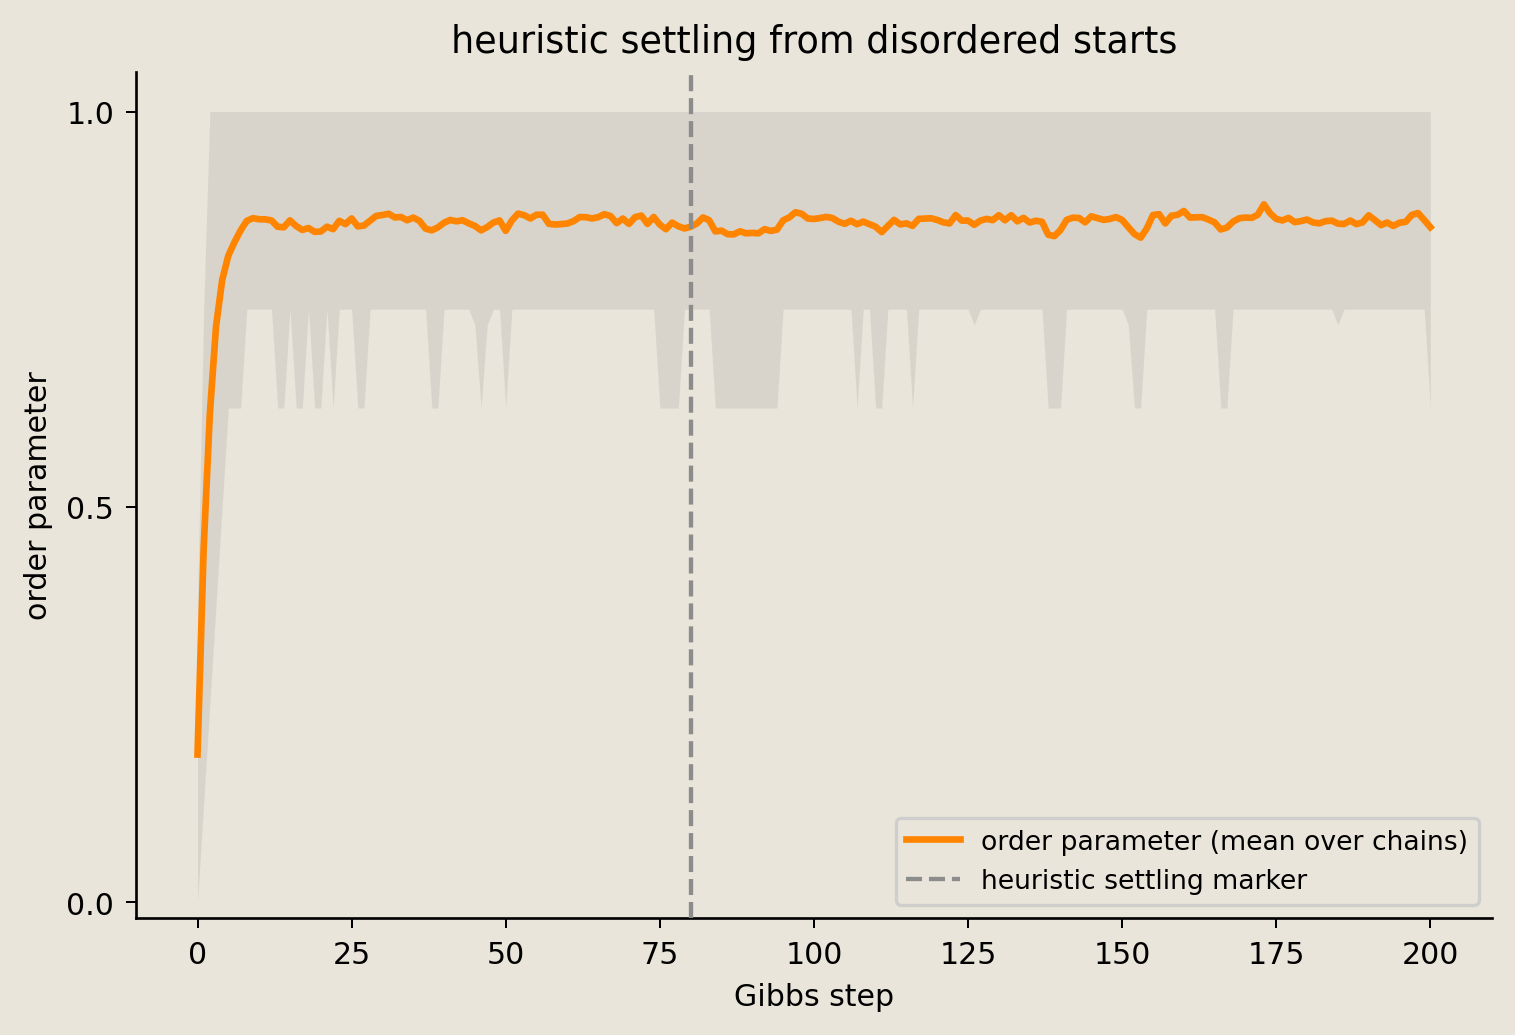

In [27]:
fig = P_samp.plot_settling_trace(order_traces, settling_step=settling_mark)
savefig(fig, "16_settling_trace")

The first comparison asks whether the sampler reproduces the right distribution of total magnetization, the sum of all spins in each sample. We enumerate the exact distribution for the zero-field case and put the two histograms side by side.

At this inverse temperature the magnet is ordered, so the exact histogram should have two peaks, one for each of the two mirror-image ordered states. We summarise the difference between the histograms with the [total variation distance](https://en.wikipedia.org/wiki/Total_variation_distance_of_probability_measures), which is half the summed absolute probability difference across magnetization bins. It ranges from 0 for identical histograms to 1 for disjoint histograms.

In [28]:
# Enumerate all 2**16 configurations once: bits and spins.
ALL_BITS = ((np.arange(2**N)[:, None] >> np.arange(N - 1, -1, -1)) & 1).astype(np.int8)
ALL_SPINS = (2 * ALL_BITS - 1).astype(np.int8)
edge_i = np.array([i for i, _ in EDGES])
edge_j = np.array([j for _, j in EDGES])




In [29]:
def exact_distribution(field):
    """Exact Boltzmann probabilities over all 2**16 configs for a fixed field."""
    agreement = (ALL_SPINS[:, edge_i] * ALL_SPINS[:, edge_j]).sum(axis=1)
    energy = -J * agreement - ALL_SPINS @ np.asarray(field, dtype=float)
    logp = -beta * energy
    logp -= logp.max()
    p = np.exp(logp)
    return p / p.sum()




In [30]:
exact_p = exact_distribution(np.zeros(N))
exact_mag = ALL_SPINS.sum(axis=1)

levels = np.arange(-N, N + 1, 2)
exact_level_probs = np.array([exact_p[exact_mag == m].sum() for m in levels])
sampler_mag = P_samp.total_magnetization(samples)
sampler_level_probs = np.array([(sampler_mag == m).mean() for m in levels])
mag_gap = (
    0.5 * np.abs(sampler_level_probs - exact_level_probs).sum()
)  # total variation on magnetization

print(f"exact distribution sums to {exact_p.sum():.6f}")
print(f"gap to exact (magnetization total variation) = {mag_gap:.4f}")

exact distribution sums to 1.000000
gap to exact (magnetization total variation) = 0.0222


Overlaid on the exact line, the sampled counts reproduce both peaks and the trough between them, at a total variation distance of 0.0222 from the exact distribution.

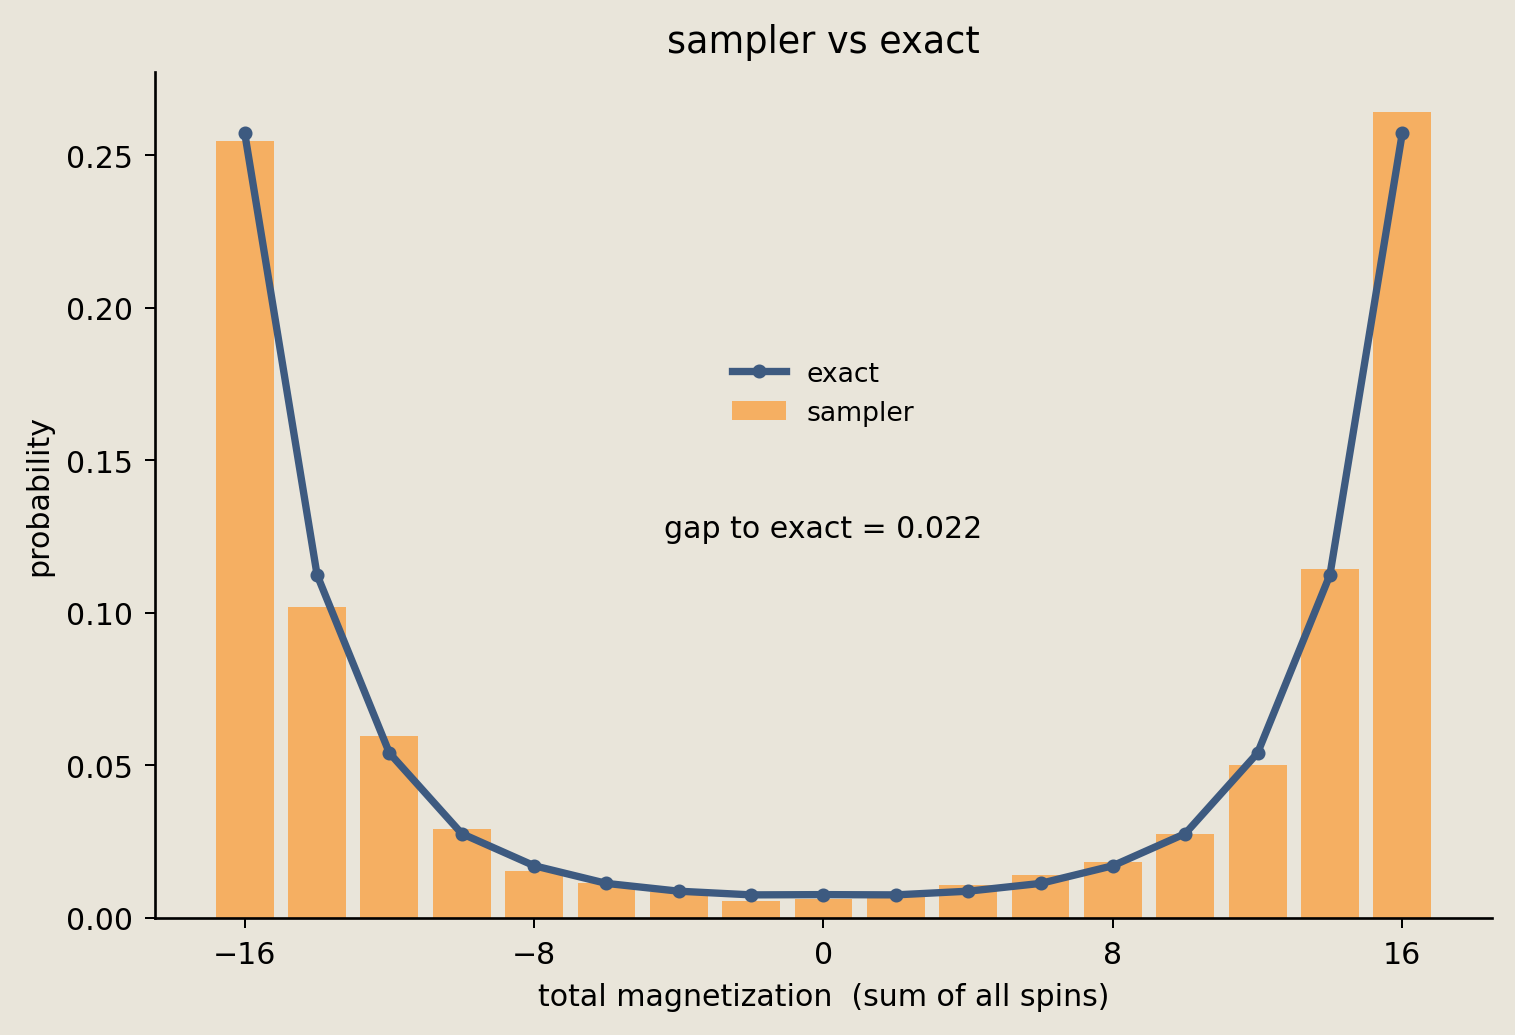

In [31]:
fig = P_samp.plot_magnetization_histogram_lattice(sampler_mag, levels, exact_level_probs, gap=mag_gap)
savefig(fig, "16_magnetization_vs_exact")

## Cooling the model

As the magnet cools, it orders, and the order parameter is how we measure that: 0 when the lattice has no net direction, 1 when it is fully aligned.

We sweep six inverse temperatures from 0.10 to 0.60 and compare three curves, each answering a different question. Enumeration gives the exact order parameter for this $4\times4$ torus, so it is the ground truth. The sampler curve tells us whether the chain recovers that truth across the whole temperature range rather than only at the baseline we used above. The [mean-field approximation](https://www.scholarpedia.org/article/Mean_field_theory) replaces each spin's neighbors with their expected average, which discards exactly the fluctuations that dominate near a transition, so we expect it to part company with the other two curves in the middle of the range.

Two reference points explain where that disagreement comes from. Mean field predicts zero order below its own critical inverse temperature $\beta = 1/(4J) = 0.25$, while the infinite square lattice has the [exact critical point](#ref-onsager1944) $\beta_c J = \tfrac{1}{2}\log(1+\sqrt{2}) \approx 0.4407$. This $4\times4$ torus is too small to have a true phase transition at either value. What it has instead is a [finite-size crossover](#ref-fisher1972), the smooth change a finite system shows in place of a singular transition, near that infinite-lattice point.

<details class="tx-disclosure"><summary>Where the sampler curve comes from</summary><p>The sampler curve comes from <code>sweep_temperatures</code> in <code>examples/helpers/_plots_sampling.py</code>, which runs fresh chains at each inverse temperature and reports their order parameter.</p></details>

In [32]:
def exact_order(beta_val):
    """Exact order parameter E|mean spin| at a given inverse temperature."""
    agreement = (ALL_SPINS[:, edge_i] * ALL_SPINS[:, edge_j]).sum(axis=1)
    logp = beta_val * (J * agreement)  # zero field
    logp -= logp.max()
    p = np.exp(logp)
    p /= p.sum()
    abs_mean_spin = np.abs(ALL_SPINS.mean(axis=1))
    return float((p * abs_mean_spin).sum())




In [33]:
def mean_field_order(beta_val, iters=500):
    """Self-consistent mean-field magnetization m = tanh(4*beta*J*m)."""
    m = 0.9
    for _ in range(iters):
        m = np.tanh(4.0 * beta_val * J * m)
    return abs(m)

In [34]:
betas = np.linspace(0.10, 0.60, 6)
exact_curve = np.array([exact_order(b) for b in betas])
mf_curve = np.array([mean_field_order(b) for b in betas])
sampler_curve = P_samp.sweep_temperatures(
    run,
    betas,
    n_chains=2000,
    seed=SEED + 10,
)

print("beta      exact   sampler  mean-field")
for b, e, s, m in zip(betas, exact_curve, sampler_curve, mf_curve, strict=True):
    print(f"{b:.2f}     {e:.3f}    {s:.3f}    {m:.3f}")

beta      exact   sampler  mean-field
0.10     0.249    0.246    0.000
0.20     0.343    0.343    0.000
0.30     0.520    0.512    0.659
0.40     0.765    0.776    0.891
0.50     0.919    0.926    0.958
0.60     0.973    0.972    0.982


Plotted together, the sampler stays within 0.012 of the exact curve at every inverse temperature, while mean field runs high through the crossover region, reading 0.659 against the exact 0.520 at $\beta = 0.30$.

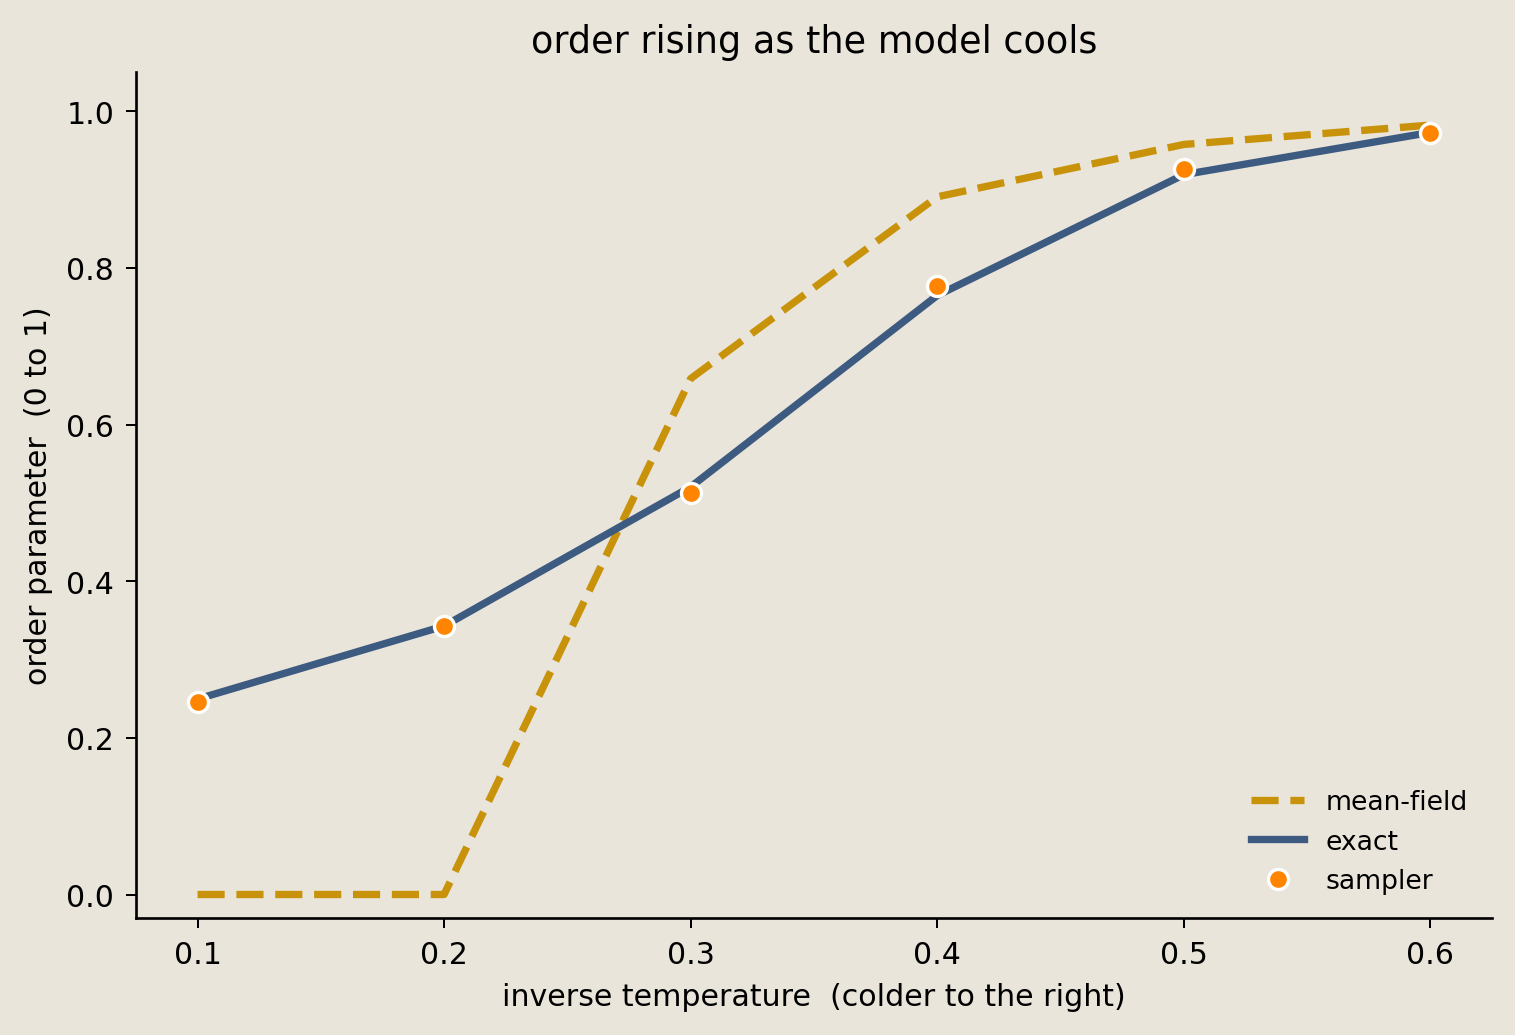

In [35]:
fig = P_samp.plot_temperature_sweep(betas, exact_curve, sampler_curve, mf_curve)
savefig(fig, "16_temperature_sweep")

## Checking against the exact answer

Matching a magnetization histogram is a coarse test, because many different samplers could produce the same one. For a fixed field the Boltzmann distribution over 16 spins is small enough to enumerate, which is what `exact_distribution` computes, so with that exact reference in hand we can match the sampler spin by spin and connection by connection instead.

To make this check meaningful, we drive the model with a field that varies from site to site. The spins are no longer all equivalent, so each one has its own exact marginal to be checked against.

The left panel shows the average value of each spin. The right panel shows the average agreement across each connection, sampler against exact.

In [36]:
parity_field = jnp.asarray(rng.normal(0.0, 0.6, size=N), dtype=jnp.float32)

parity_keys = jax.random.split(jax.random.key(SEED + 20), n_chains)
parity_inits = (
    jax.random.bernoulli(jax.random.key(SEED + 21), 0.5, (n_chains, N)).astype(
        jnp.int32
    )
    * 2
    - 1
)
parity_samples = np.asarray(
    run_many(parity_keys, jnp.asarray(beta, jnp.float32), parity_inits, parity_field)
)



In [37]:
# exact per-spin magnetization and per-connection agreement at this field
exact_pf = exact_distribution(np.asarray(parity_field))
exact_spin = (exact_pf[:, None] * ALL_SPINS).sum(axis=0)
exact_conn = np.array(
    [float((exact_pf * ALL_SPINS[:, i] * ALL_SPINS[:, j]).sum()) for i, j in EDGES]
)



In [38]:
# sampler per-spin magnetization and per-connection agreement
sampler_spin = parity_samples.mean(axis=0)
sampler_conn = np.array(
    [(parity_samples[:, i] * parity_samples[:, j]).mean() for i, j in EDGES]
)



In [39]:
spin_err = float(np.max(np.abs(sampler_spin - exact_spin)))
conn_err = float(np.max(np.abs(sampler_conn - exact_conn)))
print(f"max per-spin error       = {spin_err:.4f}")
print(f"max per-connection error = {conn_err:.4f}")

max per-spin error       = 0.0293
max per-connection error = 0.0232


Each spin and each connection becomes one point, sampler against exact, so a point on the dashed diagonal means the sampler recovered the exact value. Every point sits on the diagonal to within 0.0293 per spin and 0.0232 per connection, and the spread along the diagonal comes from the per-site field, which pulls different spins to different magnetizations.

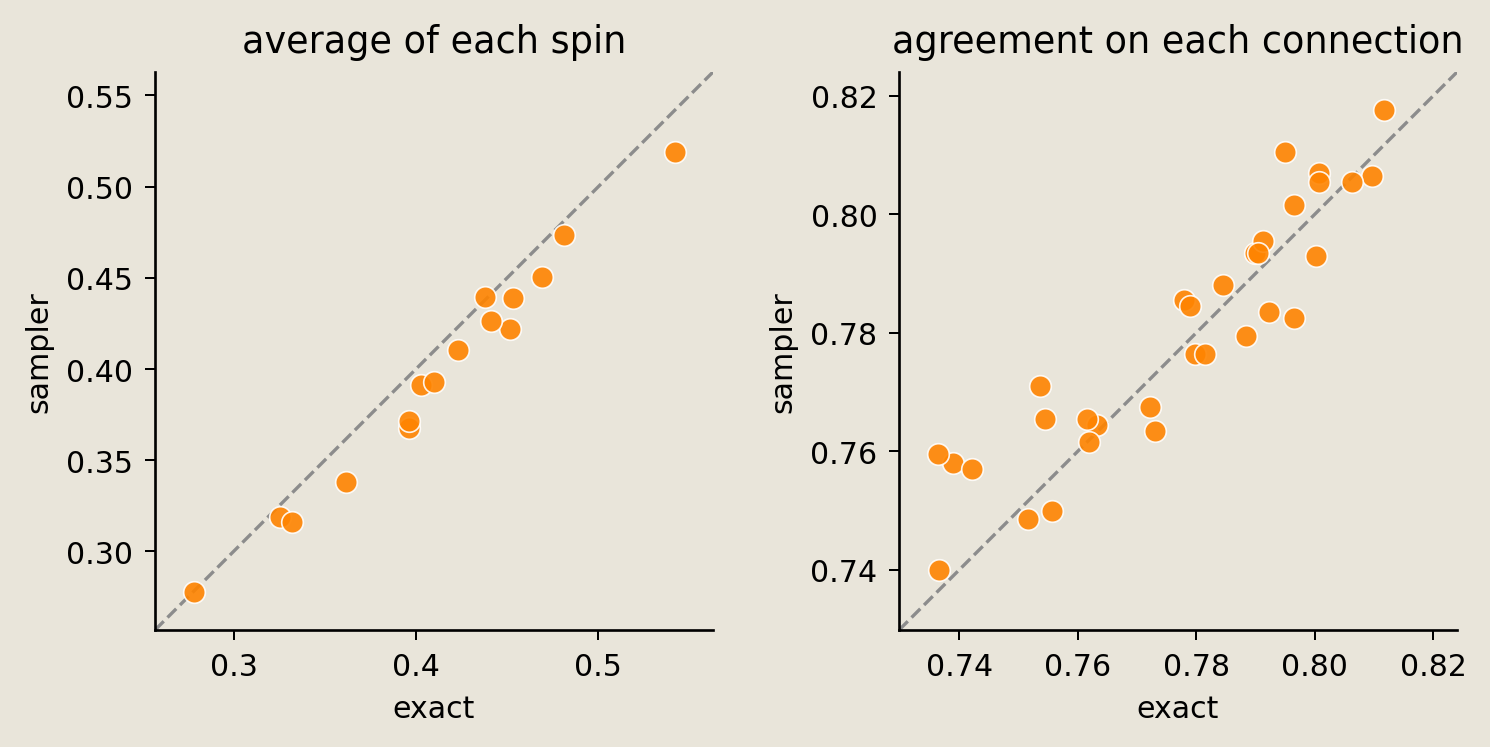

In [40]:
fig = P_samp.plot_parity(exact_spin, sampler_spin, exact_conn, sampler_conn)
savefig(fig, "16_parity")

## Driving it with a field

Because the `field` is an input, the same graph can perform field-conditioned pattern completion.

We set a field of magnitude 6 on a few sites, leave the rest at zero, and run the chain. The selected spins remain stochastic, so this finite field biases them strongly toward its sign rather than pinning them, while the zero-field sites fill in around them. That distinction is why the verification below checks the biased-site marginals against the exact field-conditioned distribution rather than checking the sign alone.

This is the field-conditioned Boltzmann machine, $P(\text{spins} \mid \text{field})$. Between this and the plots above, only the `field` input changes.

In [41]:
# strongly bias a few top-half sites toward +1 and a few bottom-half toward -1
pattern = np.zeros(N)
bias_up = [0, 3, 5]
bias_down = [10, 12, 15]
pattern[bias_up] = +1.0
pattern[bias_down] = -1.0

field_magnitude = 6.0
# the finite field biases selected sites without holding their spins fixed
field = field_magnitude * jnp.asarray(pattern, dtype=jnp.float32)



In [42]:
n_complete = 3000
complete_keys = jax.random.split(jax.random.key(SEED + 20), n_complete)
complete_init = (
    jax.random.bernoulli(jax.random.key(SEED + 21), 0.5, (n_complete, N)).astype(
        jnp.int32
    )
    * 2
    - 1
)
completed = np.asarray(
    run_many(complete_keys, jnp.asarray(beta, jnp.float32), complete_init, field)
)

one_sample = completed[0]
average = completed.mean(axis=0)



In [43]:
# exact conditional at this field: run() feeds the kernel beta*field as the drive
# and exact_distribution applies beta to the same raw field, so they match.
exact_complete = exact_distribution(np.asarray(field))
exact_avg = (exact_complete[:, None] * ALL_SPINS).sum(axis=0)



In [44]:
biased_mask = np.asarray(pattern) != 0.0
# check biased-site marginals and alignment against the exact field-conditioned result
biased_align = float(
    np.mean(np.sign(average[biased_mask]) == np.sign(np.asarray(field)[biased_mask]))
)
biased_marginal_err = float(np.max(np.abs(average[biased_mask] - exact_avg[biased_mask])))
complete_err = float(np.max(np.abs(average - exact_avg)))
print(f"biased sites aligned with their field sign: {biased_align:.0%}")
print(f"biased-site marginal max error vs exact:   {biased_marginal_err:.4f}")
print(f"all-site marginal max error vs exact:      {complete_err:.4f}")

biased sites aligned with their field sign: 100%
biased-site marginal max error vs exact:   0.0039
all-site marginal max error vs exact:      0.0316


The figure has three panels. The first is the field we imposed, where colored sites carry positive or negative bias with $|b_i|=6$ and pale sites have $b_i=0$. The other two show what the chain did with it: one field-conditioned sample, and the mean spin across all 3,000 chains.

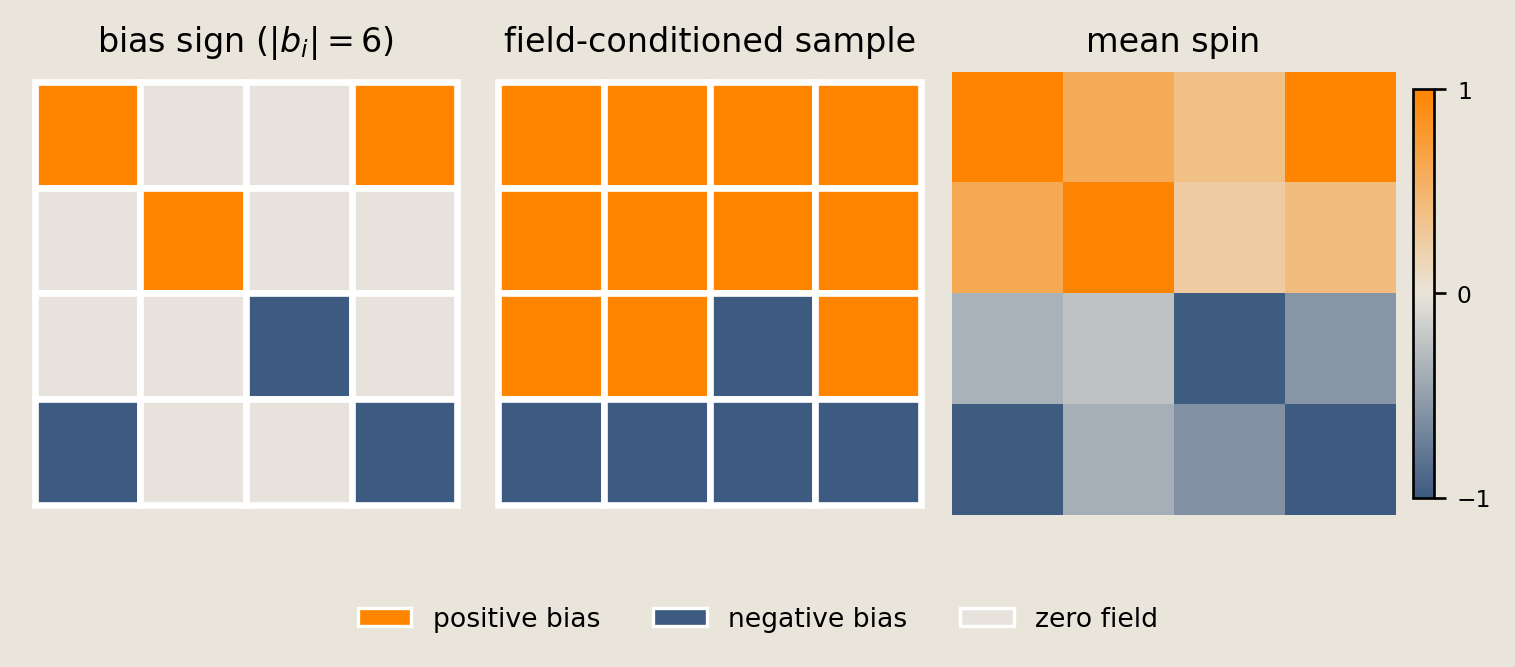

In [45]:
fig = P_samp.plot_pattern_completion(np.asarray(field), one_sample, average)
savefig(fig, "16_pattern_completion")

## Verification

We gather the quantitative checks for this tutorial in one place, and we assert them rather than only printing them, so a drift in any number fails the notebook. The single-spin probe is checked against its own analytic sigmoid conditional, which tests the factor in isolation from the graph. The magnetization, per-spin, per-connection, temperature, and field-completion checks are all measured against the brute-force exact distribution, which is the one reference here that carries no sampling error of its own.

In [46]:
# enforce the printed claims instead of only printing them
assert abs(probe_p - target_p) < 0.02, (
    f"single-spin probe {probe_p:.4f} off target {target_p:.4f}"
)
assert mag_gap < 0.10, f"magnetization gap {mag_gap:.4f} >= 0.10"
assert spin_err < 0.10, f"max per-spin error {spin_err:.4f} >= 0.10"
assert conn_err < 0.10, f"max per-connection error {conn_err:.4f} >= 0.10"
# cooling raises the order parameter monotonically (warm -> cold)
np.testing.assert_array_less(-np.diff(exact_curve), 1e-9)
assert exact_curve[-1] > exact_curve[0], "order parameter did not rise with cooling"
# temperature sweep: the sampler curve tracks the exact enumeration
temp_err = float(np.max(np.abs(sampler_curve - exact_curve)))
assert temp_err < 0.08, f"temperature sweep off exact by {temp_err:.4f}"
# field-conditioned completion: sampler marginals match exact enumeration and the
# biased sites align with their field sign
assert complete_err < 0.10, f"completion marginal error {complete_err:.4f} >= 0.10"
assert biased_align > 0.99, f"biased sites did not align: {biased_align:.2f}"



In [47]:
print("all checks passed")
print(f"  single-spin probe        = {probe_p:.4f}  (target {target_p:.4f})")
print(f"  magnetization gap        = {mag_gap:.4f}  (< 0.10)")
print(f"  max per-spin error       = {spin_err:.4f}  (< 0.10)")
print(f"  max per-connection error = {conn_err:.4f}  (< 0.10)")
print(f"  temperature sweep error  = {temp_err:.4f}  (< 0.08)")
print(f"  completion marginal err  = {complete_err:.4f}  (< 0.10)")
print(f"  order parameter warm->cold = {exact_curve[0]:.3f} -> {exact_curve[-1]:.3f}")

all checks passed
  single-spin probe        = 0.9183  (target 0.9168)
  magnetization gap        = 0.0222  (< 0.10)
  max per-spin error       = 0.0293  (< 0.10)
  max per-connection error = 0.0232  (< 0.10)
  temperature sweep error  = 0.0118  (< 0.08)
  completion marginal err  = 0.0316  (< 0.10)
  order parameter warm->cold = 0.249 -> 0.973


## Conclusion

We built a Boltzmann machine from hand-written factors, sampled it with Gibbs, and checked it against an exact brute-force reference.

- A single spin update is one factor: a directed conditional that draws a pbit with value $1$ with probability $\sigma(2\gamma_i)$ and reports that same one-spin conditional through `log_probability`. The probe confirmed that the sampled fraction and the analytic value both reproduce that sigmoid.
- The two checkerboard colors are two Gibbs blocks, each with the same factor tiled across its eight spins and one shared coupling. The `DeterministicFactor` object reassembles them into one state, giving an explicit three-site `DFG` for one Gibbs sweep.
- The weight-tied `ChainFactor` object repeats the sweep into an MCMC chain. At the chosen 200-sweep runtime, the final-chain samples match the exact distribution within the reported errors, spin by spin and connection by connection.
- Cooling the model raises the order parameter through the finite-size crossover. The mean-field approximation overshoots there, and the sampler tracks the exact curve.
- Because the `field` is an input, we used the same graph for finite-field pattern completion with no change to the wiring, giving the field-conditioned Boltzmann machine $P(\text{spins} \mid \text{field})$.

[Notebook 06](06_ising_sampling_contrastive_divergence.ipynb) applies the same chromatic-Gibbs conditional idea with `PNOT` gates on an 8-spin ring. This tutorial writes that conditional as factors on a $4\times4$ torus, so the two share the update rule and coloring strategy while their graphs and Ising distributions differ.

What this notebook is really about is the `DFG`: a custom factor with an analytic conditional, tiling, weight tying, and deterministic reassembly, composed into a graph whose output we can verify exactly. Gibbs sampling was the vehicle for that tour rather than the destination. If you want Gibbs sampling as a working tool, reach for [thrml](https://github.com/extropic-ai/thrml), which is built for it.

## References

1. Extropic. 2026. [thrml](https://github.com/extropic-ai/thrml). This is the dedicated Gibbs sampling library mentioned in the motivation.
2. Extropic. 2026. [Notebook 06: Ising sampling and contrastive divergence](06_ising_sampling_contrastive_divergence.ipynb). This companion notebook implements the same chromatic-Gibbs update idea on a different 8-spin ring distribution.
3. Extropic. 2026. [Notebook 15: Introduction to factors and directed factor graphs](15_intro_to_factors.ipynb). This companion notebook introduces the factor and `DFG` APIs used here.
4. <span id="ref-ackley1985"></span>Ackley, D.H., Hinton, G.E., Sejnowski, T.J. 1985. [*A learning algorithm for Boltzmann machines*](https://www.cs.toronto.edu/~hinton/absps/cogscibm.pdf). Cognitive Science 9(1), 147-169.
5. <span id="ref-geman1984"></span>Geman, S., Geman, D. 1984. [*Stochastic relaxation, Gibbs distributions, and the Bayesian restoration of images*](https://doi.org/10.1109/TPAMI.1984.4767596). IEEE Transactions on Pattern Analysis and Machine Intelligence 6(6), 721-741.
6. <span id="ref-gonzalez2011"></span>Gonzalez, J.E., Low, Y., Gretton, A., Guestrin, C. 2011. [*Parallel Gibbs sampling: From colored fields to thin junction trees*](https://proceedings.mlr.press/v15/gonzalez11a.html). Proceedings of AISTATS 15, 324-332.
7. <span id="ref-fisher1972"></span>Fisher, M.E., Barber, M.N. 1972. [*Scaling theory for finite-size effects in the critical region*](https://doi.org/10.1103/PhysRevLett.28.1516). Physical Review Letters 28, 1516-1519.
8. <span id="ref-onsager1944"></span>Onsager, L. 1944. [*Crystal statistics. I. A two-dimensional model with an order-disorder transition*](https://doi.org/10.1103/PhysRev.65.117). Physical Review 65, 117-149.

